In [1]:
import pandas as pd
import numpy as np

sig_100 = pd.read_csv('100_signal.csv')          #ECG waveform
ann_100 = pd.read_csv('100_annotations.csv')     #Beat annotations

sig_208 = pd.read_csv('208_signal.csv')
ann_208 = pd.read_csv('208_annotations.csv')

print("Record 100 (signal) shape:", sig_100.shape)
print("Record 100 (annotations) shape:", ann_100.shape)

print("Record 208 (signal) shape:", sig_208.shape)
print("Record 208 (annotations) shape:", ann_208.shape)

Record 100 (signal) shape: (650000, 3)
Record 100 (annotations) shape: (2274, 5)
Record 208 (signal) shape: (650000, 3)
Record 208 (annotations) shape: (3040, 5)


In [2]:
RR_100 = np.diff(ann_100["Sample"].values)
RR_208 = np.diff(ann_208["Sample"].values)

In [3]:
import pandas as pd

#states are slow, normal, fast
bins = np.quantile(RR_100, [0, 0.33, 0.66, 1])
states = np.digitize(RR_100, bins) - 1 

#build transition matrix
n_states = len(np.unique(states))
transition = np.zeros((n_states, n_states))

for i in range(len(states)-1):
    transition[states[i], states[i+1]] += 1

transition = transition / transition.sum(axis=1, keepdims=True)

transition_df = pd.DataFrame(transition, columns=[f"State {i}" for i in range(n_states)],
                             index=[f"State {i}" for i in range(n_states)])

print(transition_df)

          State 0   State 1   State 2   State 3
State 0  0.637660  0.241084  0.119829  0.001427
State 1  0.238866  0.460189  0.300945  0.000000
State 2  0.092883  0.277443  0.629674  0.000000
State 3  0.000000  1.000000  0.000000  0.000000


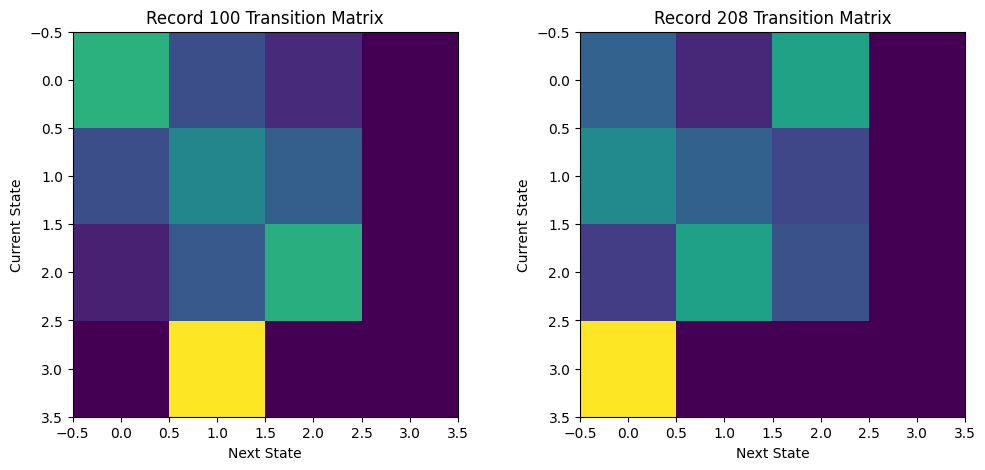

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_transition_matrix(rr):
    bins = np.quantile(rr, [0, 0.33, 0.66, 1])
    states = np.digitize(rr, bins) - 1
    n_states = len(np.unique(states))
    transition = np.zeros((n_states, n_states))
    for i in range(len(states)-1):
        transition[states[i], states[i+1]] += 1
    transition = transition / transition.sum(axis=1, keepdims=True)
    return transition

transition_100 = compute_transition_matrix(RR_100)
transition_208 = compute_transition_matrix(RR_208)

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].imshow(transition_100)
axs[0].set_title("Record 100 Transition Matrix")
axs[0].set_xlabel("Next State")
axs[0].set_ylabel("Current State")

axs[1].imshow(transition_208)
axs[1].set_title("Record 208 Transition Matrix")
axs[1].set_xlabel("Next State")
axs[1].set_ylabel("Current State")

plt.show()

We fit the model by estimating a Markov transition matrix that captures how the heart transitions between fast, normal, and slow beat states, and we generated synthetic RR sequences by simulating state transitions from this matrix. The main limitation is that a first-order Markov model only depends on the immediately preceding beat, while real arrhythmias unfold over multi-beat episodes, so the synthetic arrhythmic sequences appear less structured and less clinically realistic than the original data.

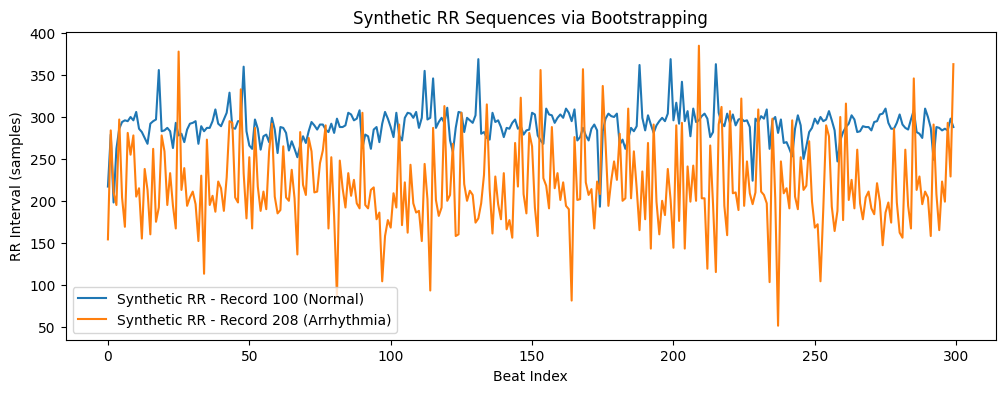

In [5]:
import matplotlib.pyplot as plt

def generate_synthetic_rr_simple(rr, n_beats=300):
    #same states as before: slow, normal, fast
    bins = np.quantile(rr, [0, 0.33, 0.66, 1])
    states = np.digitize(rr, bins) - 1

    #building transition matrix
    n_states = len(np.unique(states))
    transition = np.zeros((n_states, n_states))
    for i in range(len(states)-1):
        transition[states[i], states[i+1]] += 1
    transition = transition / transition.sum(axis=1, keepdims=True)

    #grouping rr values by state
    state_values = {s: rr[states == s] for s in range(n_states)}

    #generating new sequence
    synthetic_rr = []
    current_state = np.random.choice(n_states)  #random initial state
    for _ in range(n_beats):
        value = np.random.choice(state_values[current_state])
        synthetic_rr.append(value)
        #transition to next state
        current_state = np.random.choice(n_states, p=transition[current_state])
    
    return np.array(synthetic_rr)

syn_100 = generate_synthetic_rr_simple(RR_100, n_beats=300)
syn_208 = generate_synthetic_rr_simple(RR_208, n_beats=300)

plt.figure(figsize=(12,4))
plt.plot(syn_100, label="Synthetic RR - Record 100 (Normal)")
plt.plot(syn_208, label="Synthetic RR - Record 208 (Arrhythmia)")
plt.title("Synthetic RR Sequences via Bootstrapping")
plt.xlabel("Beat Index")
plt.ylabel("RR Interval (samples)")
plt.legend()
plt.show()

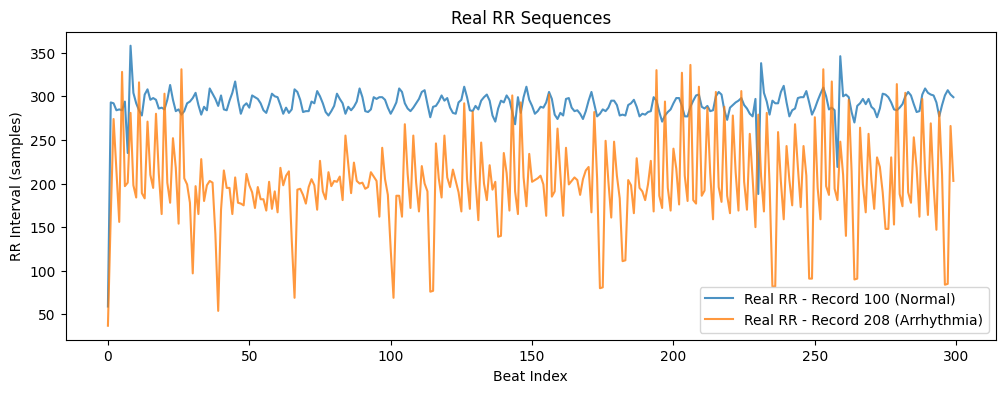

In [6]:
import matplotlib.pyplot as plt

#use 300 beats again to match synthetic plot
real_rr_100 = RR_100[:300]
real_rr_208 = RR_208[:300]

plt.figure(figsize=(12,4))
plt.plot(real_rr_100, label="Real RR - Record 100 (Normal)", alpha=0.8)
plt.plot(real_rr_208, label="Real RR - Record 208 (Arrhythmia)", alpha=0.8)
plt.title("Real RR Sequences")
plt.xlabel("Beat Index")
plt.ylabel("RR Interval (samples)")
plt.legend()
plt.show()